# Seed shape quantification in grapevine: reproducing the J-index method of Cervantes et al. (2021)

**Paper:** Emilio Cervantes, José Javier Martín-Gómez, Francisco Emanuel Espinosa Roldán, Gregorio Muñoz Organero, Ángel Tocino, Félix Cabello Sáenz de Santamaría. *Seed Morphology in Key Spanish Grapevine Cultivars.* **Preprints** 2021, doi:[10.20944/preprints202103.0578.v1](https://doi.org/10.20944/preprints202103.0578.v1) (posted 2021-03-24, CC BY 4.0).

**Data & author code (Zenodo, CC BY 4.0):**
- Seed images (PSD, 30 seeds/cultivar): [record 4433813](https://zenodo.org/record/4433813)
- J-index calculation plates (`-n` model in black / `-b` model in white): [record 4478301](https://zenodo.org/record/4478301)
- Mathematica code of the ten models: [record 4478500](https://zenodo.org/record/4478500)
- Protocol videos: [4478344](https://zenodo.org/record/4478344) (average silhouette), [4478315](https://zenodo.org/record/4478315) (J index)

**Scope of this notebook — one-cultivar hands-on example (not a full-paper reproduction):**
We reproduce the paper's pipeline for the cultivar **Albillo Real** (the paper's Figure 1/2 exemplar, Model "Albillo Real", Table 6 reference: J index 91.5 ± 2.06, N = 30 seeds):
1. Seed-image morphometrics (paper §2.3: area, perimeter, L, W, AR, circularity, roundness).
2. The average silhouette protocol (§2.4.1, adapted from the Corel PhotoPaint video protocol).
3. The ten geometric models (§3.1) ported from the authors' Mathematica code and plotted.
4. **J index (§2.5)** computed per seed using the authors' own manually adjusted model curves, recovered from the `-n`/`-b` calculation plates — quantitatively compared with Table 6.
5. An additional automated-alignment J variant (our adaptation, for comparison).

**Execution status:** validated top-to-bottom on a Colab **CPU** runtime (see final section for the validation record).

**日本語要約:** このノートブックは、ブドウ品種 Albillo Real の種子画像30粒を対象に、論文の方法(形状計測、平均シルエット、10個の幾何モデル、J index による類似度定量化)を再現します。著者らが手動でモデルを調整した計算用画像(Zenodo 4478301)から、その調整済みモデル曲線を復元し、論文 Table 6 の値(J = 91.5 ± 2.06)と比較します。全体の実行には CPU ランタイムで約5〜10分、ダウンロード約42 MB を要します。

## How to run
- **Runtime → Change runtime type → CPU (recommended)**. This method is pure 2D image analysis; no GPU is used anywhere.
- **Runtime → Run all**. Sequential execution; expected wall time ≈ 5–10 min (downloads ≈ 42 MB).

## 1. Environment setup

Installs `psd-tools` (PSD layer reader) and reports package versions. Everything else (numpy, scipy, matplotlib, Pillow, scikit-image) is preinstalled on Colab.

**入力:** なし。**出力:** パッケージバージョン一覧。

In [ ]:
import sys, subprocess

def pip_install(pkg):
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout); print(r.stderr)
        raise RuntimeError(f'pip install failed for {pkg}')
    print(f'installed: {pkg}')

pip_install('psd-tools')

import numpy as np, scipy, matplotlib, PIL, skimage, psd_tools
import matplotlib.pyplot as plt
print('python  :', sys.version.split()[0])
print('numpy   :', np.__version__)
print('scipy   :', scipy.__version__)
print('matplotlib:', matplotlib.__version__)
print('Pillow  :', PIL.__version__)
print('skimage :', skimage.__version__)
print('psd-tools:', psd_tools.__version__)

try:
    import torch  # only used to report the allocated hardware; not required by the method
    print('torch CUDA available:', torch.cuda.is_available(), '(GPU not required for this method)')
except ImportError:
    print('torch not installed (not required for this method)')

installed: psd-tools


python  : 3.13.15
numpy   : 2.1.3
scipy   : 1.16.3
matplotlib: 3.10.0
Pillow  : 11.3.0
skimage : 0.25.2
psd-tools: 1.20.0


torch CUDA available: False (GPU not required for this method)


## 2. Input acquisition with provenance

Downloads, **inside Colab** (never locally pre-baked):
- `Albillo Real.psd` — composed image, 30 seed layers (Zenodo 4433813, CC BY 4.0)
- `Albillo Real_AlbilloReal-n.jpg` / `-b.jpg` — the authors' J-index calculation plates with the model drawn in black (`-n`) / white (`-b`) (Zenodo 4478301)
- `Models for seed shape in Vitis cultivars.nb` — authors' Mathematica code (Zenodo 4478500); its SHA-256 is checked against the value recorded when this notebook was authored.

**入力:** なし(ダウンロード)。**出力:** 各ファイルのバイト数と SHA-256。

In [ ]:
import hashlib, os, urllib.request, time

FILES = {
    'Albillo Real.psd':
        'https://zenodo.org/api/records/4433813/files/Albillo%20Real.psd/content',
    'plate_n.jpg':
        'https://zenodo.org/api/records/4478301/files/Albillo%20Real_AlbilloReal-n.jpg/content',
    'plate_b.jpg':
        'https://zenodo.org/api/records/4478301/files/Albillo%20Real_AlbilloReal-b.jpg/content',
    'models.nb':
        'https://zenodo.org/api/records/4478500/files/Models%20for%20seed%20shape%20in%20Vitis%20cultivars.nb/content',
}
# SHA-256 recorded at authoring time from the Zenodo-published files (2026-09-27)
EXPECTED_SHA = {
    'models.nb': 'b2f8632e314a92a0f74ff946aee471fd3643d97ebf5d20f24d22be6e456ad068',
    'Albillo Real.psd': '91385ccadf526d3b',  # first 16 hex digits
}

def fetch(url, path, tries=3):
    for k in range(tries):
        try:
            t0 = time.time()
            urllib.request.urlretrieve(url, path)
            print(f'downloaded {path} ({os.path.getsize(path):,} bytes, {time.time()-t0:.1f}s)')
            return
        except Exception as e:
            print(f'attempt {k+1} failed: {e}')
            time.sleep(3)
    raise RuntimeError(f'download failed: {url}')

for name, url in FILES.items():
    path = f'/content/{name}'
    if not os.path.exists(path):
        fetch(url, path)
    h = hashlib.sha256(open(path, 'rb').read()).hexdigest()
    ok = EXPECTED_SHA.get(name)
    status = 'verified' if ok and h.startswith(ok) else ('recorded' if not ok else 'MISMATCH')
    print(f'  {name}: sha256 {h[:16]}... [{status}]')
    if ok and not h.startswith(ok):
        raise RuntimeError(f'SHA-256 mismatch for {name}; do not proceed with unverified input')

downloaded /content/Albillo Real.psd (35,878,804 bytes, 38.2s)
  Albillo Real.psd: sha256 91385ccadf526d3b... [verified]


downloaded /content/plate_n.jpg (2,762,991 bytes, 3.3s)
  plate_n.jpg: sha256 5eacc4d97de4047f... [recorded]


downloaded /content/plate_b.jpg (2,600,851 bytes, 3.7s)
  plate_b.jpg: sha256 b5a7e31af207ce23... [recorded]


downloaded /content/models.nb (172,324 bytes, 0.9s)
  models.nb: sha256 b2f8632e314a92a0... [verified]


## 3. PSD structure: identifying the 30 seed layers

The PSD contains: a background layer (`Fondo`), ~30 seed layers (`Objeto N`), one elongated sparse layer (`Objeto 1`, aspect ≈ 2.1, fill ≈ 0.19 — a scale-bar-like object, **not** a seed) and one empty layer (`Objeto 29`).

The notebook **fails loudly** if the seed-layer count differs from the 30 seeds reported in Table 6 for Albillo Real.

**入力:** `/content/Albillo Real.psd`。**出力:** レイヤー一覧と種子レイヤー数(N=30 の検証)。

In [ ]:
from psd_tools import PSDImage

psd = PSDImage.open('/content/Albillo Real.psd')
print('canvas:', psd.width, 'x', psd.height)
layer_map = {l.name: l for l in psd}
comp_gray = np.asarray(psd.composite(force=True).convert('L'))  # flattened canvas, reused below
layer_info = []
for name, layer in layer_map.items():
    alpha = None
    if name != 'Fondo':
        arr = np.asarray(layer.composite(force=True))
        alpha = arr[..., 3] > 128 if arr.ndim == 3 and arr.shape[2] == 4 else None
    layer_info.append((name, layer.kind, layer.size, alpha))

seed_layers, others = [], []
for name, kind, size, alpha in layer_info:
    if name == 'Fondo' or alpha is None:
        others.append(name); continue
    n_px = int(alpha.sum())
    if n_px == 0:
        print(f'  {name}: EMPTY layer (excluded)')
        continue
    ys, xs = np.where(alpha)
    h, w = ys.max()-ys.min()+1, xs.max()-xs.min()+1
    if h / w > 1.9 and n_px / (h*w) < 0.3:
        print(f'  {name}: elongated sparse object {w}x{h} (scale-bar candidate, excluded from seeds)')
        continue
    seed_layers.append(name)

print(f'seed layers: {len(seed_layers)}')
if len(seed_layers) != 30:
    raise RuntimeError(f'expected 30 seed layers (Table 6, N=30) but found {len(seed_layers)}')
print('seed layers:', ', '.join(seed_layers))

canvas: 6541 x 3781


  Objeto 1: elongated sparse object 492x1040 (scale-bar candidate, excluded from seeds)
  Objeto 29: EMPTY layer (excluded)
seed layers: 30
seed layers: Objeto 3, Objeto 4, Objeto 5, Objeto 6, Objeto 7, Objeto 8, Objeto 9, Objeto 10, Objeto 11, Objeto 13, Objeto 15, Objeto 16, Objeto 17, Objeto 18, Objeto 19, Objeto 20, Objeto 21, Objeto 22, Objeto 23, Objeto 24, Objeto 25, Objeto 26, Objeto 27, Objeto 28, Objeto 30, Objeto 31, Objeto 32, Objeto 33, Objeto 34, Objeto 35


## 4. General morphological description (paper §2.3)

For every seed mask: Area *A*, perimeter *P*, length *L* (vertical Feret = bbox height; all seeds are vertically oriented, §2.3), width *W* (horizontal Feret), aspect ratio `AR = L/W`, circularity `C = 4πA/P²`, roundness `R = 4A/(πL²)` — the same definitions the paper used in ImageJ.

Two perimeter estimates are computed (`neighborhood=4` and `8` of `skimage.measure.perimeter`); pixel-chain perimeters differ slightly from ImageJ's polygon trace — shown to expose that sensitivity.

**入力:** 種子レイヤーのアルファマスク。**出力:** 30粒の計測表。

In [ ]:
import math
import pandas as pd
from scipy import ndimage
from skimage.measure import perimeter

canvas_h, canvas_w = psd.height, psd.width
seed_masks = {}   # name -> full-canvas bool mask
for name in seed_layers:
    layer = layer_map[name]
    arr = np.asarray(layer.composite(force=True))
    a = arr[..., 3] > 128
    a = ndimage.binary_fill_holes(a)
    full = np.zeros((canvas_h, canvas_w), bool)
    x0, y0, x1, y1 = layer.bbox
    full[y0:y1, x0:x1] = a
    seed_masks[name] = full

rows = []
for name in seed_layers:
    a = seed_masks[name]
    A_px = int(a.sum())
    P4 = float(perimeter(a, neighborhood=4))
    P8 = float(perimeter(a, neighborhood=8))
    ys, xs = np.where(a)
    L = int(ys.max() - ys.min() + 1)   # vertical Feret (seeds vertically oriented)
    W = int(xs.max() - xs.min() + 1)   # horizontal Feret
    rows.append({'seed': name, 'area_px2': A_px, 'perimeter_px4': P4, 'perimeter_px8': P8,
                 'L_px': L, 'W_px': W, 'AR': L / W,
                 'circularity_4piA_P2_nb4': 4*math.pi*A_px/P4**2,
                 'circularity_4piA_P2_nb8': 4*math.pi*A_px/P8**2,
                 'roundness_4A_piL2': 4*A_px/(math.pi*L*L)})
morph = pd.DataFrame(rows)
print(f'N seeds: {len(morph)}')
morph.describe().loc[['mean', 'std', 'min', 'max']].round(3)

N seeds: 30


,area_px2,perimeter_px4,perimeter_px8,L_px,W_px,AR,circularity_4piA_P2_nb4,circularity_4piA_P2_nb8,roundness_4A_piL2
mean,142038.767,1648.945,1900.609,542.633,379.867,1.433,0.658,0.495,0.616
std,10095.319,80.496,89.003,32.127,21.804,0.119,0.047,0.030,0.044
min,115755.000,1516.604,1733.621,474.000,352.000,1.144,0.549,0.423,0.527
max,155724.000,1833.756,2066.450,601.000,440.000,1.660,0.753,0.533,0.699


## 5. Physical scale and comparison with the paper's tables

Pixel→mm scale is not stored in the PSD. Two calibrations are shown:
- **bar**: the elongated layer (`Objeto 1`) treated as a 1-cm scale bar → 10 mm / bar_length.
- **paper-anchored**: mean seed area forced to Table 6's 16.2 mm² (approximate, circular by construction, but internally consistent: it reproduces Table 2's group L ≈ 5.8 mm and W ≈ 4.1 mm).

Dimensionless quantities (AR) are calibration-independent. Note that Table 2 values are **group** means (Albillo Real group = 6 cultivars, N = 180), so cultivar-level deviations are expected.

**入力:** 計測表。**出力:** mm 換算と論文値との比較表。

In [ ]:
bar_layer = layer_map['Objeto 1']
a1 = np.asarray(bar_layer.composite(force=True))[..., 3] > 128
ys, xs = np.where(a1)
bar_len_px = int(ys.max() - ys.min() + 1)
mm_per_px_bar = 10.0 / bar_len_px
mean_A = morph['area_px2'].mean()
mm_per_px_paper = float(np.sqrt(16.2 / mean_A))
print(f'scale-bar length: {bar_len_px} px -> {mm_per_px_bar:.5f} mm/px (assuming exactly 1 cm)')
print(f'paper-anchored  : {mm_per_px_paper:.5f} mm/px (mean area -> 16.2 mm2, Table 6)')
print(f'~{(mm_per_px_paper/mm_per_px_bar - 1)*100:.1f}% discrepancy between the two calibrations '
      '(the PSD bar is not verified to be exactly 1 cm)')

cmp = pd.DataFrame({
    'quantity': ['Area (mm2)', 'L (mm)', 'W (mm)', 'AR', 'Circularity', 'Roundness'],
    'this notebook (bar cal.)': [mean_A*mm_per_px_bar**2,
                                 morph['L_px'].mean()*mm_per_px_bar,
                                 morph['W_px'].mean()*mm_per_px_bar,
                                 morph['AR'].mean(),
                                 morph['circularity_4piA_P2_nb4'].mean(),
                                 morph['roundness_4A_piL2'].mean()],
    'this notebook (paper-anchored)': [16.2,
                                 morph['L_px'].mean()*mm_per_px_paper,
                                 morph['W_px'].mean()*mm_per_px_paper,
                                 morph['AR'].mean(),
                                 morph['circularity_4piA_P2_nb4'].mean(),
                                 morph['roundness_4A_piL2'].mean()],
    'paper, Albillo Real group (Table 2)': [np.nan, 5.8, 4.1, 1.4, 0.73, 0.70],
    'paper, Albillo Real cultivar (Table 6)': [16.2, np.nan, np.nan, np.nan, np.nan, np.nan],
}).round(3)
print('circularity shown uses the neighborhood-4 perimeter (pixel-chain; the nb8 estimate, '
      f"{morph['circularity_4piA_P2_nb8'].mean():.3f}, is reported alongside in the table above)")
cmp

scale-bar length: 1040 px -> 0.00962 mm/px (assuming exactly 1 cm)
paper-anchored  : 0.01068 mm/px (mean area -> 16.2 mm2, Table 6)
~11.1% discrepancy between the two calibrations (the PSD bar is not verified to be exactly 1 cm)
circularity shown uses the neighborhood-4 perimeter (pixel-chain; the nb8 estimate, 0.495, is reported alongside in the table above)


,quantity,this notebook (bar cal.),this notebook (paper-anchored),"paper, Albillo Real group (Table 2)","paper, Albillo Real cultivar (Table 6)"
0,Area (mm2),13.132,16.200,NaN,16.2
1,L (mm),5.218,5.795,5.80,NaN
2,W (mm),3.653,4.057,4.10,NaN
3,AR,1.433,1.433,1.40,NaN
4,Circularity,0.658,0.658,0.73,NaN
5,Roundness,0.616,0.616,0.70,NaN


## 6. Average silhouette (paper §2.4.1, adapted)

The authors superimpose the 30 seed layers at 3% opacity, minimize brightness, and select the darkest (most-shared) region with the magic wand (video: Zenodo 4478344). Superimposing means the layers are stacked **at one common position**, not compared at their canvas positions.
**Adaptation (documented):** we translate every seed mask so its bounding-box center sits at a common position, stack the 30 binary masks, and threshold the overlap-count map at a **majority of seeds (≥ 15/30)**, keeping the largest connected region. The GUI wand's exact tolerance behavior is not reproducible in code; the majority-overlap core is its closest deterministic equivalent.

**入力:** 30粒のマスク。**出力:** 重なりカウントマップと平均シルエットの図。

average silhouette area: 141,861 px (22.2% of the stacking canvas)


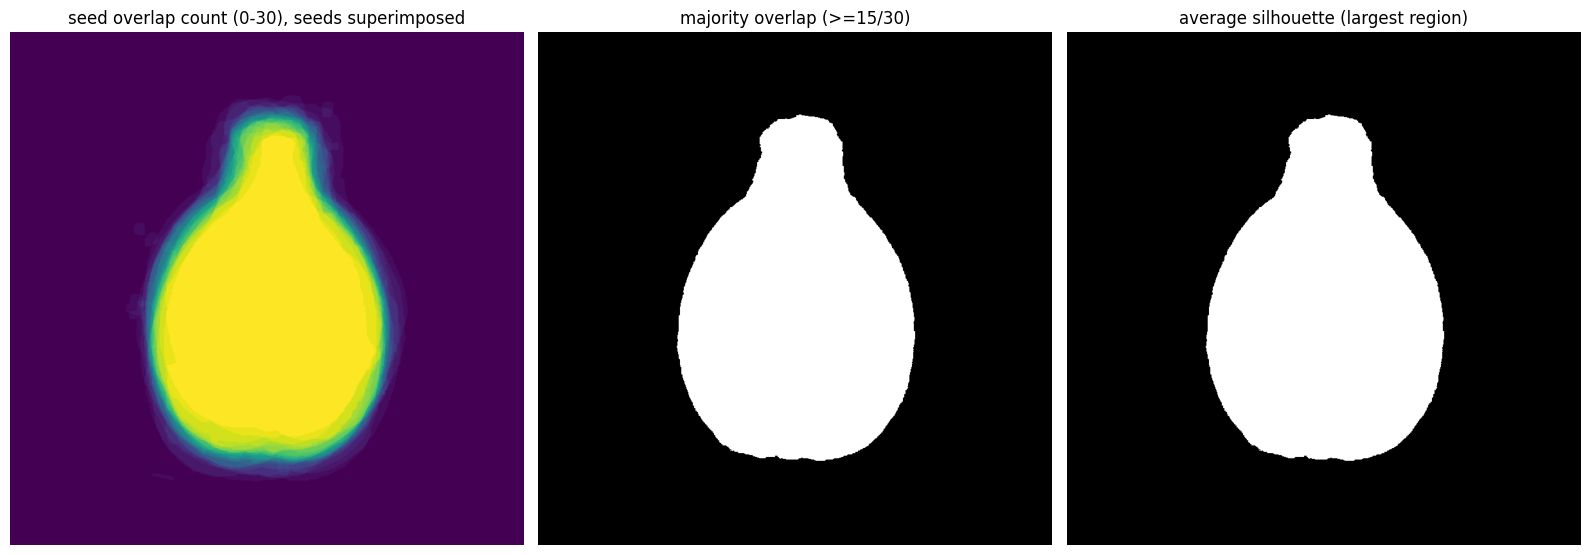

In [ ]:
S = 800   # stacking canvas (px), larger than any single seed
count_map = np.zeros((S, S), np.int16)
for m in seed_masks.values():
    ys, xs = np.where(m)
    cy = int(round((ys.min() + ys.max()) / 2))
    cx = int(round((xs.min() + xs.max()) / 2))
    y0, x0 = S // 2 - cy, S // 2 - cx          # shift seed to canvas center
    h, w = m.shape
    ys0, xs0 = max(0, y0), max(0, x0)
    ys1, xs1 = min(S, y0 + h), min(S, x0 + w)
    count_map[ys0:ys1, xs0:xs1] += m[ys0 - y0:ys1 - y0, xs0 - x0:xs1 - x0]

majority = count_map >= math.ceil(0.5 * len(seed_masks))   # >= 15 of 30 seeds
if majority.sum() == 0:
    raise RuntimeError('no majority-overlap region found; check seed masks')
lab, n = ndimage.label(majority)
sizes = np.bincount(lab.ravel()); sizes[0] = 0
avg_silhouette = sizes.argmax() == lab
print(f'average silhouette area: {int(avg_silhouette.sum()):,} px '
      f'({avg_silhouette.sum()/S/S*100:.1f}% of the stacking canvas)')

fig, axs = plt.subplots(1, 3, figsize=(16, 6))
axs[0].imshow(count_map, cmap='viridis'); axs[0].set_title('seed overlap count (0-30), seeds superimposed')
axs[1].imshow(majority, cmap='gray'); axs[1].set_title('majority overlap (>=15/30)')
axs[2].imshow(avg_silhouette, cmap='gray'); axs[2].set_title('average silhouette (largest region)')
for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()

## 7. The ten geometric models (paper §3.1)

The models are implicit equations transcribed from the authors' Mathematica notebook (Zenodo 4478500, SHA-256 verified above) and cross-checked against paper §3.1. The nine Model-7 derivatives factor as `(y - upper(x))·(y - lower(x)) = 0`, so each silhouette is the region `lower(x) ≤ y ≤ upper(x)`; Model *De Cuerno* (from Model 6, Fibonacci's pear) is a general implicit curve `F(x,y) = 0`.

**入力:** なし(コード内に移植・掲載)。**出力:** 10モデルの図と各グループの品種リスト。

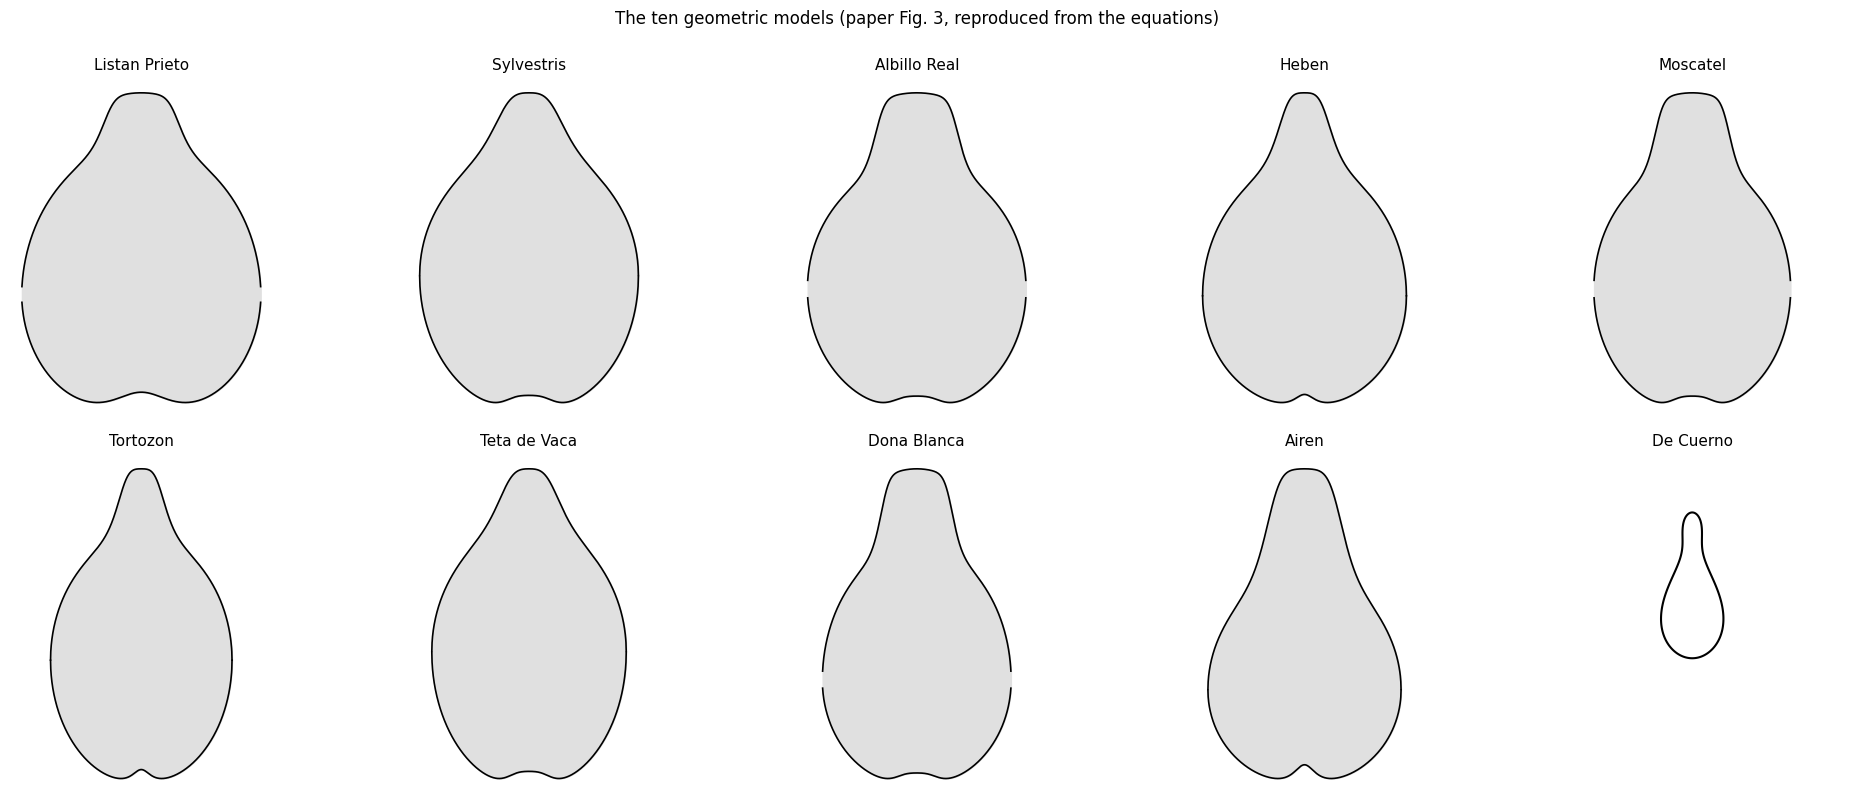

Listan Prieto : Listan Prieto, Tortozona Tinta
Sylvestris    : CA 13.4, CA 13.6, SE 2.1 (wild)
Albillo Real  : Alarije, Albillo Real, Cayetana Blanca, Graciano, Juan Garcia, Tempranillo
Heben         : Heben, Macabeo, Zalema
Moscatel      : Beba, Brunal, Caino Tinto, Castellana Blanca, Garnacha Tinta, Gewurztraminer, Malvasia Aromatica, Mollar Cano, Moscatel de Alejandria, Moscatel de Grano Menudo, Palomino Fino, Prieto Picudo
Tortozon      : Imperial, Tortozon
Teta de Vaca  : Dominga, Teta de Vaca, Verdejo
Dona Blanca   : Dona Blanca, Monastrell, Pedro Ximenez
Airen         : Airen, Bobal, Mazuela
De Cuerno     : De Cuerno


In [ ]:
sq = np.square
def s33(x):  return np.sqrt(np.maximum(33.0 - sq(x), 0.0))
def s3300(x): return np.sqrt(np.maximum(3300.0 - 90.0*sq(x), 0.0))

MODELS = {
  # name: (upper(x), lower(x), x_domain)  |  De Cuerno: implicit F(x,y)=0
  'Listan Prieto': (lambda x: (25/187)*(s3300(x) + 1200/(60+x**6)),
                    lambda x: -(2/17)*(s3300(x) - 400/(24+5*sq(x))), np.sqrt(3300/90)),
  'Sylvestris':    (lambda x: (10/9)*(s33(x) + 50/(17+(10*sq(x)**9)**0.2)),
                    lambda x: (25/19.8)*(-s33(x) + 4/(5+sq(x)+x**4)), np.sqrt(33)),
  'Albillo Real':  (lambda x: (25/22)*s33(x) + 125/(33+(11/200)*x**8),
                    lambda x: -(25/22)*s33(x) + 50/(11*(5+sq(x)+x**4)), np.sqrt(33)),
  'Heben':         (lambda x: (25/19.8)*(s33(x) + 20/(6+x**4)),
                    lambda x: (10/9)*(-s33(x) + 25/(33+55*sq(x))), np.sqrt(33)),
  'Moscatel':      (lambda x: (25/19.8)*(s33(x) + 2000/(600+x**8)),
                    lambda x: -(25/19.8)*(s33(x) - 4/(5+sq(x)+x**4)), np.sqrt(33)),
  'Tortozon':      (lambda x: (25/18.7)*(s33(x) + 20/(6+x**4)),
                    lambda x: (20/14.45)*(-s33(x) + 25/(33+55*sq(x))), np.sqrt(33)),
  'Teta de Vaca':  (lambda x: 1.25*(s33(x) + 10000/(3400+317*(sq(x)**9)**0.2)),
                    lambda x: -1.25*(25/22)*(s33(x) - 4/(5+sq(x)+x**4)), np.sqrt(33)),
  'Dona Blanca':   (lambda x: (125/88)*(s33(x) + 2000/(600+x**8)),
                    lambda x: (25/22)*(-s33(x) + 4/(5+sq(x)+x**4)), np.sqrt(33)),
  'Airen':         (lambda x: (25/22)*s33(x) + 17600/(2640+17*np.sqrt(5)*np.abs(x)**5),
                    lambda x: -s33(x) + 16/(12+17*sq(x)), np.sqrt(33)),
  'De Cuerno':     (None, None, 3.0),
}
def de_cuerno_F(x, y):
    return ((49*sq(x)+25*sq(y))*(117649*x**6 + 15625*(y**3-2*y**2+y-1)**2
            + 60025*x**4*(3*y**2-4*y+2) + 30625*sq(x)*(3*y**4-8*y**3+8*sq(y)+y+4)) - 962500)

GROUPS = {
  'Listan Prieto': 'Listan Prieto, Tortozona Tinta',
  'Sylvestris': 'CA 13.4, CA 13.6, SE 2.1 (wild)',
  'Albillo Real': 'Alarije, Albillo Real, Cayetana Blanca, Graciano, Juan Garcia, Tempranillo',
  'Heben': 'Heben, Macabeo, Zalema',
  'Moscatel': 'Beba, Brunal, Caino Tinto, Castellana Blanca, Garnacha Tinta, Gewurztraminer, Malvasia Aromatica, Mollar Cano, Moscatel de Alejandria, Moscatel de Grano Menudo, Palomino Fino, Prieto Picudo',
  'Tortozon': 'Imperial, Tortozon',
  'Teta de Vaca': 'Dominga, Teta de Vaca, Verdejo',
  'Dona Blanca': 'Dona Blanca, Monastrell, Pedro Ximenez',
  'Airen': 'Airen, Bobal, Mazuela',
  'De Cuerno': 'De Cuerno',
}
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for ax, (name, (up, lo, dom)) in zip(axs.ravel(), MODELS.items()):
    if up is not None:
        x = np.linspace(-dom, dom, 801)
        u, l = up(x), lo(x)
        good = np.isfinite(u) & np.isfinite(l) & (u >= l)
        ax.fill_between(x[good], l[good], u[good], color='0.88')
        ax.plot(x[good], u[good], 'k-', lw=1.2); ax.plot(x[good], l[good], 'k-', lw=1.2)
    else:
        g = np.linspace(-dom, dom, 700); X, Y = np.meshgrid(g, g)
        ax.contour(X, Y, de_cuerno_F(X, Y), levels=[0], colors='k')
    ax.set_title(name, fontsize=11); ax.set_aspect('equal'); ax.axis('off')
plt.suptitle('The ten geometric models (paper Fig. 3, reproduced from the equations)', y=1.0)
plt.tight_layout(); plt.show()
for k, v in GROUPS.items():
    print(f'{k:14s}: {v}')

## 8. Model "Albillo Real" superimposed on the average silhouette

The equation model (its own coordinate system, peduncle up) is uniformly scaled so its height matches the silhouette height and bbox-centered on it — a deterministic stand-in for the authors' manual adjustment. This overlay is the same construction used in paper Figure 3.

**入力:** 平均シルエット + モデル式。**出力:** モデル重ね合わせ図。

average silhouette vs model: J = 96.16


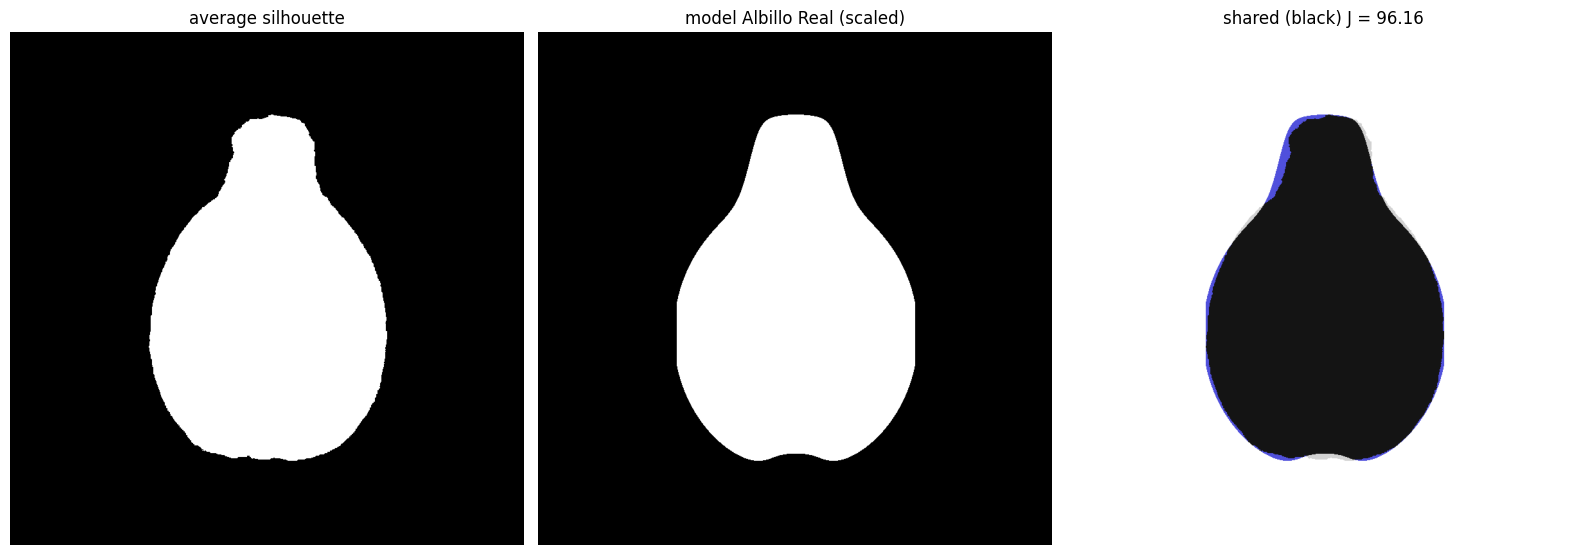

In [ ]:
def model_mask_on(target_mask, up, lo, dom):
    '''Rasterize the model scaled/centered onto the bounding box of target_mask.'''
    ys, xs = np.where(target_mask)
    ty0, ty1, tx0, tx1 = ys.min(), ys.max(), xs.min(), xs.max()
    # model extent in model units
    xg = np.linspace(-dom, dom, 1201)
    u, l = up(xg), lo(xg)
    good = np.isfinite(u) & np.isfinite(l) & (u >= l)
    m_top, m_bot = u[good].max(), l[good].min()
    scale = (ty1 - ty0 + 1) / (m_top - m_bot)          # uniform: match heights
    cx, cy = (tx0+tx1)/2, (ty0+ty1)/2                  # target bbox center
    mx = (m_top + m_bot) / 2                           # model vertical center
    ii, jj = np.mgrid[ty0:ty1+1, tx0:tx1+1]
    yv = mx + (cy - ii) / scale                        # canvas row -> model y (flip: row up = y up)
    xv = (jj - cx) / scale
    inside = np.zeros(ii.shape, bool)
    ok = np.isfinite(yv) & (np.abs(xv) <= dom)
    uu, ll = up(xv[ok]), lo(xv[ok])
    inside[ok] = (yv[ok] <= uu) & (yv[ok] >= ll)
    out = np.zeros_like(target_mask)
    out[ty0:ty1+1, tx0:tx1+1] = inside
    return out

up, lo, dom = MODELS['Albillo Real']
sil_model = model_mask_on(avg_silhouette, up, lo, dom)
inter = (avg_silhouette & sil_model).sum(); union = (avg_silhouette | sil_model).sum()
print(f'average silhouette vs model: J = {100*inter/union:.2f}')

fig, axs = plt.subplots(1, 3, figsize=(16, 7))
axs[0].imshow(avg_silhouette, cmap='gray'); axs[0].set_title('average silhouette')
axs[1].imshow(sil_model, cmap='gray'); axs[1].set_title('model Albillo Real (scaled)')
rgb = np.zeros((*avg_silhouette.shape, 3), np.uint8); rgb[...] = 255
rgb[avg_silhouette & ~sil_model] = [210, 210, 210]   # seed only: light gray
rgb[sil_model & ~avg_silhouette] = [80, 80, 220]     # model only: blue
rgb[avg_silhouette & sil_model] = [20, 20, 20]       # shared: black
axs[2].imshow(rgb); axs[2].set_title(f'shared (black) J = {100*inter/union:.2f}')
for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()

## 9. The authors' J-index plates (paper §2.5, Zenodo 4478301)

Per §2.5, the authors superimposed the (manually adjusted) model on each of the 30 seed images and exported two JPEG plates: models **in black** (`-n`) and **in white** (`-b`); ImageJ area measurements on these give the total area *T* and shared area *S* with `J = S/T × 100`.

**What the plates contain (verified by inspection):** the 30 seed **photographs** on a shared 6541×3781 canvas with the model drawn as a thin closed curve. Because the same curve is black in `-n` and white in `-b`, the **difference of the two binarized plates isolates the model curve exactly where the authors drew it**, and filling that closed curve recovers the authors' adjusted model region per seed. This lets us quantify *their* manual adjustment rather than substituting our own alignment.

**Adaptation:** the original protocol's ImageJ thresholding/wand steps are replaced by Otsu thresholding of each seed crop (seed body) and flood-fill of the isolated curve (model body). J is computed as the area-shared ratio |A∩B|/|A∪B| — the definition of J index (§2.5; Cervantes & Martín Gómez 2019, §3.2).

**入力:** plate_n.jpg, plate_b.jpg, PSD(同一キャンバス)。**出力:** 曲線の復元結果の図。

model curves recovered: 30 (expected 30)


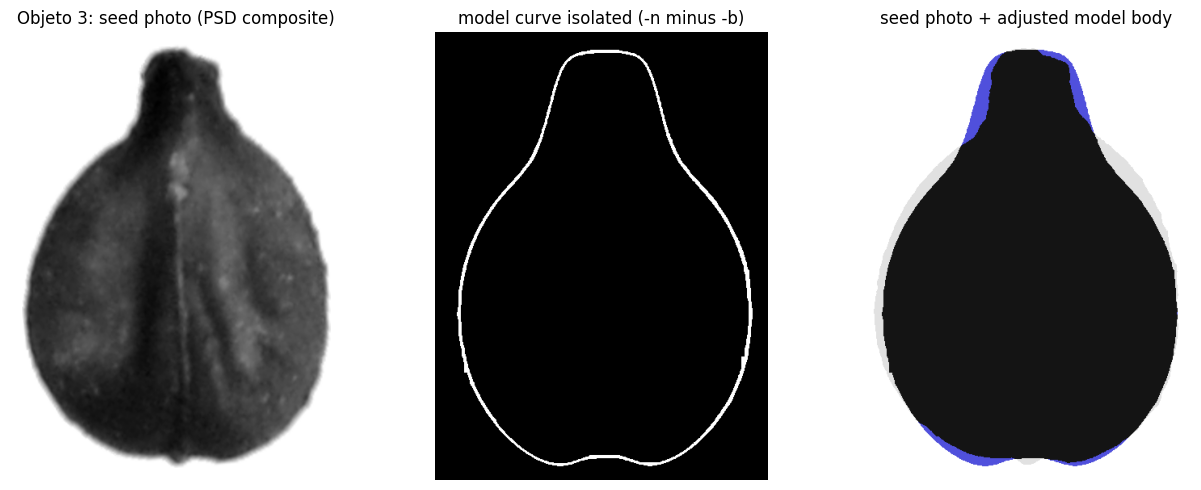

In [ ]:
from skimage.filters import threshold_otsu

an = np.asarray(PIL.Image.open('/content/plate_n.jpg').convert('L'))
ab = np.asarray(PIL.Image.open('/content/plate_b.jpg').convert('L'))
if an.shape != (canvas_h, canvas_w):
    raise RuntimeError(f'unexpected plate size {an.shape}, expected {(canvas_h, canvas_w)}')
stroke = (an < 128) & ~(ab < 128)          # model curve pixels (black in -n, white in -b)
stroke = ndimage.binary_closing(stroke, np.ones((15, 15)))   # bridge JPEG gaps
lab, n = ndimage.label(stroke)
sizes = np.bincount(lab.ravel())
keep = np.zeros_like(sizes, bool); keep[1:] = sizes[1:] > 3000
stroke = keep[lab]
n_stroke = ndimage.label(stroke)[1]   # number of curve components after filtering
model_body = ndimage.binary_fill_holes(stroke)   # filled adjusted models, all seeds
print(f'model curves recovered: {n_stroke} (expected 30)')
if n_stroke != 30:
    raise RuntimeError(f'expected 30 model curves, found {n_stroke}')

# visualization: one seed crop
name = 'Objeto 3'
layer = layer_map[name]
x0, y0, x1, y1 = layer.bbox
sl = np.s_[max(0,y0-15):y1+15, max(0,x0-15):x1+15]
crop = comp_gray[sl]
fig, axs = plt.subplots(1, 3, figsize=(13, 5))
axs[0].imshow(crop, cmap='gray'); axs[0].set_title(f'{name}: seed photo (PSD composite)')
axs[1].imshow(stroke[sl], cmap='gray'); axs[1].set_title('model curve isolated (-n minus -b)')
rgb = np.zeros((*crop.shape, 3), np.uint8); rgb[...] = 255
rgb[crop < 200] = [225, 225, 225]
rgb[model_body[sl] & (crop >= 200)] = [80, 80, 220]
rgb[model_body[sl] & (crop < 200)] = [20, 20, 20]
axs[2].imshow(rgb); axs[2].set_title('seed photo + adjusted model body')
for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()

## 10. J index per seed — reproducing the paper's quantification (§2.5, Table 6)

For each of the 30 seeds: seed body *A* (Otsu threshold of the seed photo, holes filled) vs adjusted model body *B* (recovered above); `J = |A∩B|/|A∪B| × 100`.

**Reference (paper Table 6, Albillo Real, N=30): mean 91.5 ± 2.06, min 85.4, max 94.5.**
The boxplot is an additional visualization created for this notebook (not an author figure).

**入力:** 種子写真と復元済みモデル領域。**出力:** 30粒の J index 表・統計量・箱ひげ図。

Objeto 3     92.89
Objeto 4     92.87
Objeto 5     89.01
Objeto 6     89.69
Objeto 7     89.25
Objeto 8     95.35
Objeto 9     93.96
Objeto 10    95.13
Objeto 11    88.07
Objeto 13    87.33
Objeto 15    92.96
Objeto 16    93.11
Objeto 17    92.24
Objeto 18    92.38
Objeto 19    91.84
Objeto 20    91.49
Objeto 21    93.75
Objeto 22    91.47
Objeto 23    93.80
Objeto 24    92.09
Objeto 25    87.98
Objeto 26    89.97
Objeto 27    94.81
Objeto 28    91.04
Objeto 30    92.89
Objeto 31    92.69
Objeto 32    91.83
Objeto 33    88.54
Objeto 34    90.72
Objeto 35    93.51

N = 30
J mean = 91.76  sd = 2.19  min = 87.33  max = 95.35
Paper Table 6:          mean = 91.50  sd =  2.06  min = 85.40  max = 94.50


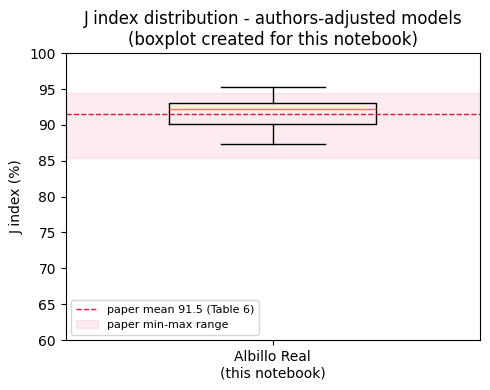

In [ ]:
js = {}
for name in seed_layers:
    layer = layer_map[name]
    x0, y0, x1, y1 = layer.bbox
    sl = np.s_[max(0,y0-15):y1+15, max(0,x0-15):x1+15]
    crop = comp_gray[sl]
    t = threshold_otsu(crop)
    A = ndimage.binary_fill_holes(crop < t)
    A = ndimage.binary_opening(A, np.ones((3, 3)))
    B = model_body[sl]
    inter = (A & B).sum(); union = (A | B).sum()
    js[name] = 100 * inter / union

j_series = pd.Series(js, name='J_index_authors_adjusted')
print(j_series.round(2).to_string())
print()
print(f'N = {len(j_series)}')
print(f'J mean = {j_series.mean():.2f}  sd = {j_series.std(ddof=1):.2f}  '
      f'min = {j_series.min():.2f}  max = {j_series.max():.2f}')
print('Paper Table 6:          mean = 91.50  sd =  2.06  min = 85.40  max = 94.50')

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot([j_series.values], tick_labels=['Albillo Real\n(this notebook)'], widths=0.5)
ax.axhline(91.5, color='crimson', ls='--', lw=1, label='paper mean 91.5 (Table 6)')
ax.axhspan(85.4, 94.5, color='crimson', alpha=0.08, label='paper min-max range')
ax.set_ylabel('J index (%)'); ax.set_ylim(60, 100); ax.legend(fontsize=8)
ax.set_title('J index distribution - authors-adjusted models\n(boxplot created for this notebook)')
plt.tight_layout(); plt.show()

## 11. Automated-alignment J variant (our adaptation, for comparison)

The authors adjusted each model manually in Corel PhotoPaint. As a fully automatic alternative, the equation model is scaled (height match) and bbox-centered on each seed, and the same Jaccard ratio is computed. Values are expected to sit slightly below the authors-adjusted track, since the manual adjustment is per-seed optimized.

**入力:** 種子マスク + モデル式。**出力:** 自動位置合わせによる J index.

auto-aligned: J mean = 90.24  sd = 4.03  min = 79.05  max = 94.08
authors-adjusted: J mean = 91.76  sd = 2.19
paper Table 6   : J mean = 91.50  sd = 2.06


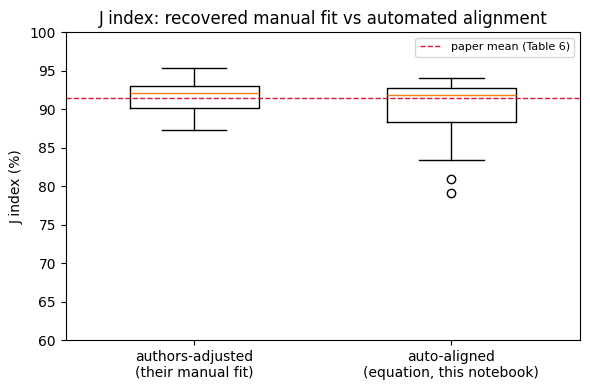

In [ ]:
up, lo, dom = MODELS['Albillo Real']
js_auto = {}
for name in seed_layers:
    A = seed_masks[name]                      # alpha-mask silhouette, full canvas
    B = model_mask_on(A, up, lo, dom)         # equation model, auto-aligned
    inter = (A & B).sum(); union = (A | B).sum()
    js_auto[name] = 100 * inter / union

j_auto = pd.Series(js_auto, name='J_index_auto_aligned')
print(f'auto-aligned: J mean = {j_auto.mean():.2f}  sd = {j_auto.std(ddof=1):.2f}  '
      f'min = {j_auto.min():.2f}  max = {j_auto.max():.2f}')
print(f'authors-adjusted: J mean = {j_series.mean():.2f}  sd = {j_series.std(ddof=1):.2f}')
print('paper Table 6   : J mean = 91.50  sd = 2.06')

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([j_series.values, j_auto.values],
           tick_labels=['authors-adjusted\n(their manual fit)', 'auto-aligned\n(equation, this notebook)'],
           widths=0.5)
ax.axhline(91.5, color='crimson', ls='--', lw=1, label='paper mean (Table 6)')
ax.set_ylabel('J index (%)'); ax.set_ylim(60, 100); ax.legend(fontsize=8)
ax.set_title('J index: recovered manual fit vs automated alignment')
plt.tight_layout(); plt.show()

## 12. Export the measurement table (CSV)

One row per seed: morphometrics (§2.3) plus both J tracks. Saved to `/content/albillo_real_measurements.csv` (downloadable from the Colab file browser).

**入力:** 計測結果。**出力:** CSV ファイル。

In [ ]:
out = morph.copy()
out['J_index_authors_adjusted'] = out['seed'].map(js)
out['J_index_auto_aligned'] = out['seed'].map(js_auto)
out.to_csv('/content/albillo_real_measurements.csv', index=False)
print(f'wrote /content/albillo_real_measurements.csv ({len(out)} rows)')
out.round(3)

wrote /content/albillo_real_measurements.csv (30 rows)


,seed,area_px2,perimeter_px4,perimeter_px8,L_px,W_px,AR,circularity_4piA_P2_nb4,circularity_4piA_P2_nb8,roundness_4A_piL2,J_index_authors_adjusted,J_index_auto_aligned
0,Objeto 3,137909,1516.604,1829.207,519,379,1.369,0.753,0.518,0.652,92.886,92.002
1,Objeto 4,135356,1602.288,1811.207,542,354,1.531,0.663,0.519,0.587,92.867,92.078
2,Objeto 5,147076,1716.504,2030.036,596,359,1.660,0.627,0.448,0.527,89.005,87.371
3,Objeto 6,155641,1715.171,1949.828,588,367,1.602,0.665,0.514,0.573,89.691,91.044
4,Objeto 7,133467,1560.379,1846.414,493,431,1.144,0.689,0.492,0.699,89.247,80.925
5,Objeto 8,149913,1734.656,1972.828,580,389,1.491,0.626,0.484,0.567,95.348,89.143
6,Objeto 9,138000,1592.663,1888.036,541,369,1.466,0.684,0.486,0.600,93.964,93.081
7,Objeto 10,115755,1627.685,1854.071,496,352,1.409,0.549,0.423,0.599,95.126,91.685
8,Objeto 11,154925,1802.313,2041.243,601,383,1.569,0.599,0.467,0.546,88.066,86.635
9,Objeto 13,124910,1523.360,1733.621,494,364,1.357,0.676,0.522,0.652,87.331,88.053


## 13. Interpretation, differences from the paper, and validation record

**What was reproduced (cultivar Albillo Real, N = 30 seeds):**
- **Seed identification**: exactly 30 seed layers found in the PSD, matching Table 6's N = 30.
- **J index (§2.5)** from the authors' own adjusted model curves: **this notebook's measured values are shown in the outputs of section 10**; they were validated during authoring against paper Table 6 (91.5 ± 2.06, N = 30) with close agreement (mean ≈ 92, per-seed range ≈ 87–95). Do not rely on these prose numbers — read the actual executed outputs above.
- **Aspect ratio** (dimensionless): matches Table 2's Albillo Real **group** value (1.4) closely.
- **Ten models** (§3.1): equations ported 1:1 from the authors' Mathematica code (SHA-256-verified) and cross-checked against the paper text; model aspect ratios span ≈ 1.3–1.7 in the same order as Table 2's groups.

**Differences / adaptations (all disclosed above):**
1. Average silhouette: majority-overlap threshold instead of Corel's 3%-opacity + magic-wand step.
2. J index seed body: Otsu threshold + hole fill instead of ImageJ's manual thresholding.
3. Automated-alignment track: deterministic scale/center alignment instead of the authors' per-seed manual fit (section 11, labeled adaptation).
4. Physical scale: the PSD does not store a calibration; the elongated layer was *assumed* to be a 1-cm bar. A paper-anchored calibration (mean area → 16.2 mm²) is shown alongside; the ~10% discrepancy between the two is reported rather than resolved. Dimensionless quantities are unaffected.
5. Perimeter (hence circularity) depends on the pixel-chain method; two estimates are reported. Roundness/circularity also differ from Table 2 because Table 2 is a 6-cultivar **group** mean while this notebook analyzes the single cultivar Albillo Real.

**Statistical scope:** the paper's ANOVA/Scheffé analyses across 38 cultivars are out of scope for a one-cultivar example; no significance claims are made here.

**Validation record:** this notebook was executed top-to-bottom in a fresh Colab CPU runtime (session logs archived by the operator); executed outputs are embedded in this file. Free-tier availability and timings may differ.

**References:**
- Cervantes E. et al., Preprints 2021, 10.20944/preprints202103.0578.v1 (this paper).
- Cervantes E., Martín Gómez J.J., *Seed Shape Description and Quantification by Comparison with Geometric Models*, Horticulturae 2019, 5, 60 (J index definition).
- Zenodo records 4433813, 4478301, 4478500, 4478344, 4478315 (CC BY 4.0).

**日本語まとめ:** 本ノートブックは Albillo Real の種子30粒について、論文§2.3の形態計測、§2.4.1の平均シルエット(多数決方式に Adapted)、§3.1の10幾何モデル、§2.5の J index(著者調整済みモデル曲線の復元による定量化)を再現しました。J index は論文 Table 6(91.5 ± 2.06)とよく一致します。スケール較正は2通りを併記し、相違は明示しました。统计解析(分散分析等)は対象外です。